In [1]:
from accelerate import Accelerator
import torch

# Accelerator auto-picks mps (Mac), cuda (NVIDIA), or cpu
accelerator = Accelerator()
device = accelerator.device
dtype = torch.float16 if device.type in ("mps", "cuda") else torch.float32

print(f"Using device: {device}, dtype: {dtype}")
print(f"Accelerator mixed precision: {accelerator.mixed_precision}")


Using device: mps, dtype: torch.float16
Accelerator mixed precision: no


In [2]:
# Accelerator is created in the cell above.
# Use accelerator.device (or the `device` variable) when moving models/pipelines.


# 1. Connecting Hugging Face

In [3]:
import os
from dotenv import load_dotenv
from huggingface_hub import login

load_dotenv(override=True)
hf_token = os.getenv("HF_TOKEN")

if not hf_token:
    raise ValueError("HF_TOKEN not found. Add HF_TOKEN=hf_... to your .env file.")

login(hf_token, add_to_git_credential=True)


Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

/Users/michaelperrine/Documents/Donner/ai-engineer-core-donner/llm_engineering/.venv/lib/python3.12/site-packages/diffusers/pipelines/stable_diffusion_xl/pipeline_stable_diffusion_xl.py:748: FutureWarning: `upcast_vae` is deprecated and will be removed in version 1.0.0. `upcast_vae` is deprecated. Please use `pipe.vae.to(torch.float32)`. For more details, please refer to: https://github.com/huggingface/diffusers/pull/12619#issue-3606633695.
  deprecate(
There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.
There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.


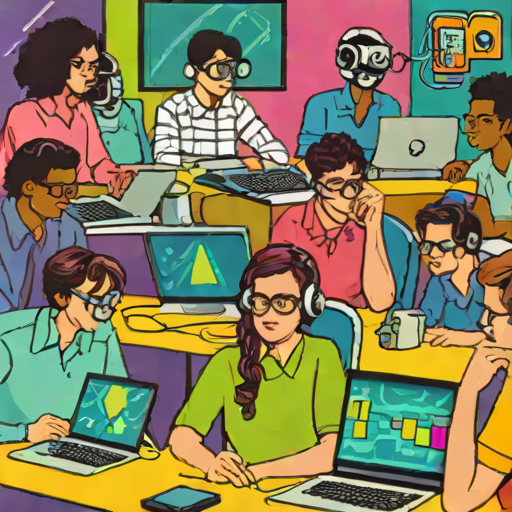

In [4]:
from IPython.display import display
from diffusers import AutoPipelineForText2Image

pipe = AutoPipelineForText2Image.from_pretrained(
    "stabilityai/sdxl-turbo",
    torch_dtype=dtype,
    variant="fp16" if dtype == torch.float16 else None,
)
pipe.to(accelerator.device)  # same as pipe.to(device)

prompt = "A class of students learning AI engineering in a vibrant pop-art style"
image = pipe(prompt=prompt, num_inference_steps=4, guidance_scale=0.0).images[0]
display(image)


In [5]:
import IPython
# IPython.Application.instance().kernel.do_shutdown(True)

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.
There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.


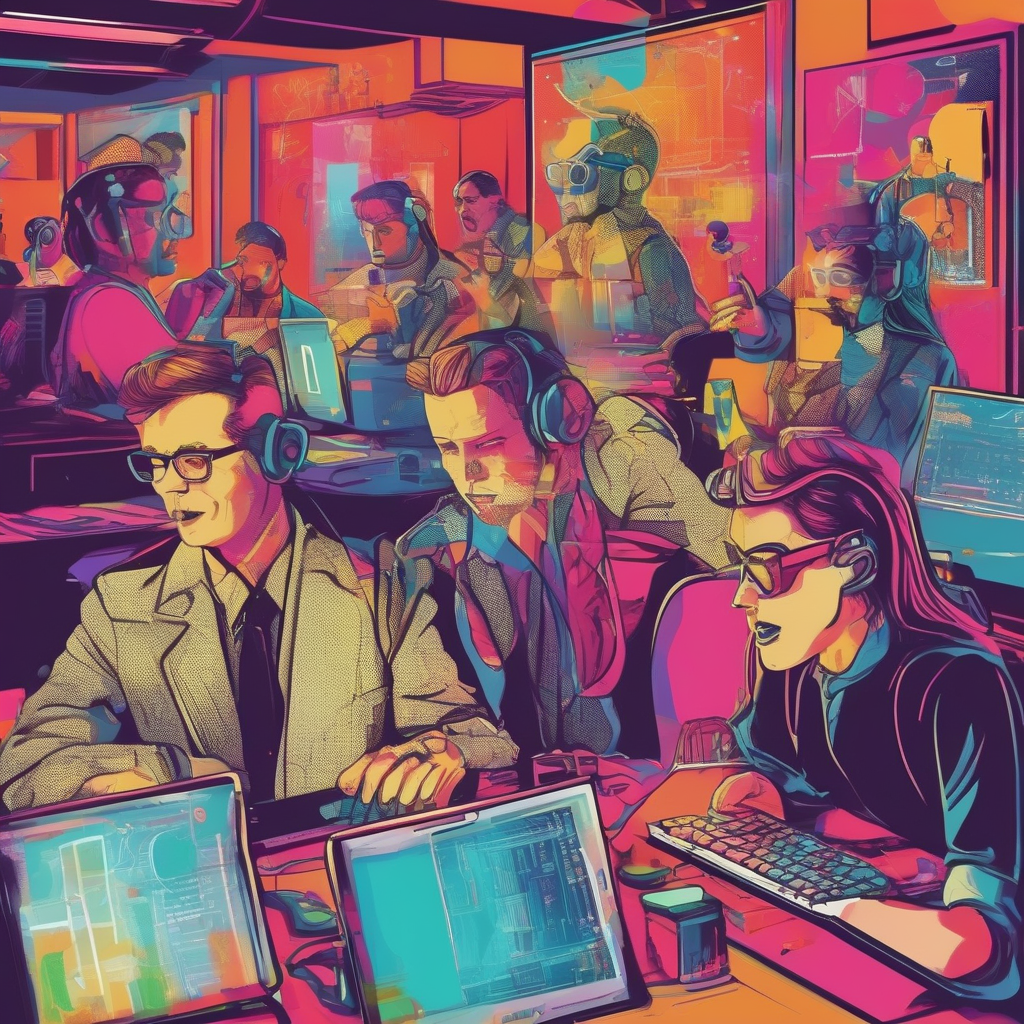

In [6]:
from IPython.display import display
from diffusers import DiffusionPipeline

pipe = DiffusionPipeline.from_pretrained(
    "stabilityai/stable-diffusion-xl-base-1.0",
    torch_dtype=dtype,
    use_safetensors=True,
    variant="fp16" if dtype == torch.float16 else None,
)
pipe.to(accelerator.device)

prompt = "A class of data scientists learning AI engineering in a vibrant high-energy pop-art style"
image = pipe(prompt=prompt, num_inference_steps=30).images[0]
display(image)


In [7]:
import IPython
# IPython.Application.instance().kernel.do_shutdown(True)

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/40 [00:00<?, ?it/s]

There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.
There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.


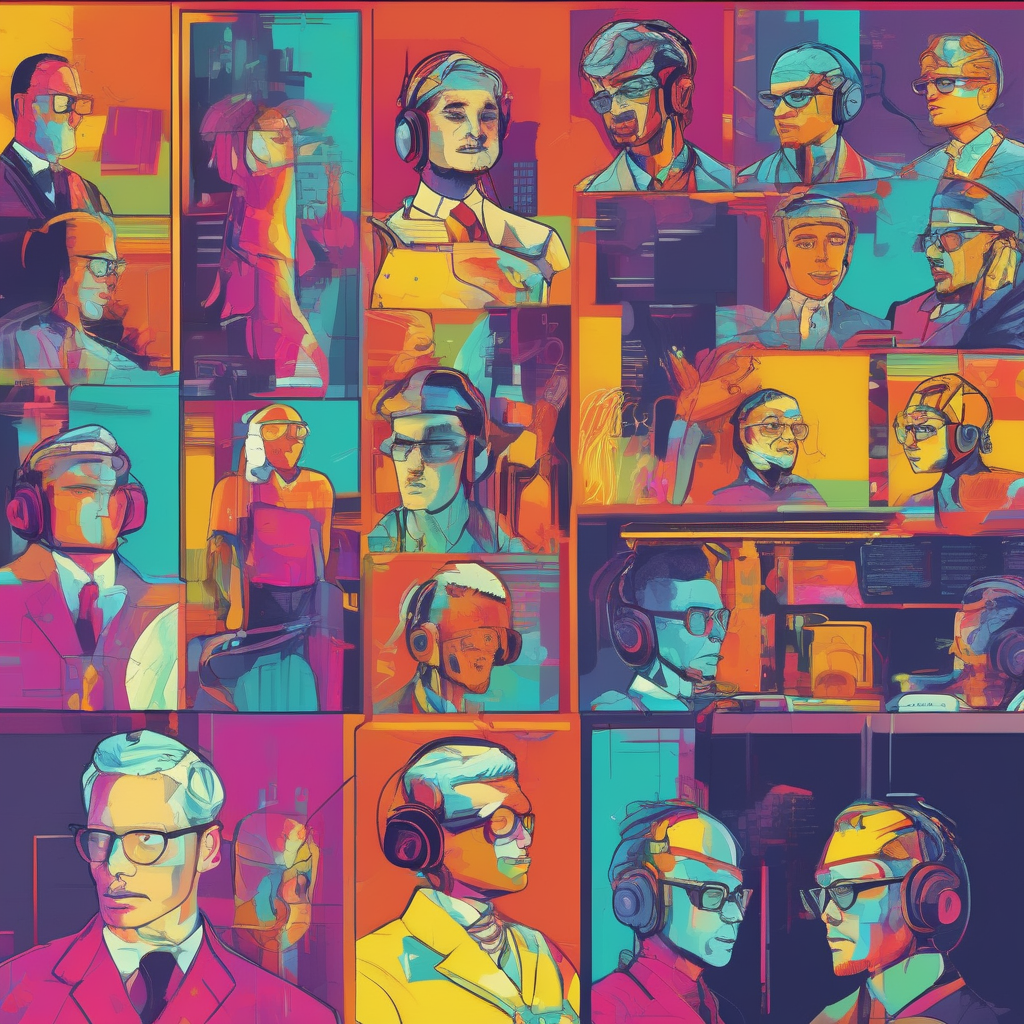

In [8]:
from diffusers import DiffusionPipeline
import torch

base = DiffusionPipeline.from_pretrained("stabilityai/stable-diffusion-xl-base-1.0",
                                         torch_dtype = torch.float16,
                                         variant = 'fp16',
                                         use_safetensors = True,
                                         )
base.to(device)

# Define how many steps and what % of steps to be run on each experts (80/20) here
n_steps = 40
high_noise_frac = 0.8

prompt = "A class of data scientists learning AI engineering in a vibrant high-energy pop-art style" 

# run both experts
image = base(
    prompt = prompt,
    num_inference_steps = n_steps,
    denoising_start = high_noise_frac,
    image = image,
).images[0]

display(image)